# Designing Custom Hoppings

In the previous section we defined custom layer geometries. The layer tells MoirePy *where* the atoms sit; the hopping parameters tell it *how strongly* they couple. By default you pass a constant float and every bond of that type gets the same amplitude. In this section we replace those constants with callables so the coupling varies bond-by-bond, driven by the actual distance between atoms.

## 1. The Six Hopping Slots

`generate_hamiltonian` accepts six parameters:

| Parameter | Description |
|-----------|-------------|
| `tll` | Intra-layer hopping inside the **lower** layer |
| `tuu` | Intra-layer hopping inside the **upper** layer |
| `tlu` | Inter-layer hopping from **lower** to **upper** |
| `tul` | Inter-layer hopping from **upper** to **lower** |
| `tlself` | On-site energy for atoms in the **lower** layer |
| `tuself` | On-site energy for atoms in the **upper** layer |

Each slot accepts either:

- A **float** or **int**: every bond of that type gets the same constant amplitude.
- Or a **callable** (a function for example): MoirePy calls it once per hopping channel and expects an array back.

You can freely mix: pass a float for `tll` and a function for `tul`. All six slots follow the same rule and default to **zero (0)** if not specified.

## 2. Function Signatures

The signature differs slightly depending on whether the parameter is a **pair-hopping** term (`tll`, `tuu`, `tlu`, `tul`) or an **on-site** term (`tlself`, `tuself`).

### Pair-hopping (`tll`, `tuu`, `tlu`, `tul`)

```python
def my_hopping(pos_i, pos_j, R, type_i, type_j, lattice, **kwargs):
    ...
    return values
```

| Argument | Type | Description |
|----------|------|-------------|
| `pos_i` | `ndarray (N, 2)` | Coordinates of the source atoms |
| `pos_j` | `ndarray (N, 2)` | Coordinates of the destination atoms. In case of PBC, this is the mapped coordinate of the atom inside the supercell. |
| `R` | `ndarray (N, 2)` | Supercell shift vectors for the point `j`. Add this to `pos_j` to get the actual coordinate of the atom. |
| `type_i` | `list[str]` of length N | Atom-type labels of source atoms (e.g. `"A"`, `"B"`) |
| `type_j` | `list[str]` of length N | Atom-type labels of destination atoms |
| `lattice` | `BilayerMoireLattice` | The full lattice object; has `theta`, `mlv1`, `mlv2`, etc. |
| `**kwargs` | any | Anything you pass via `extra_inputs` |

`N` is the total number of bonds of that hopping type in the supercell.

!!! note
    The shape of the returned value should be `(N, k, k)` where `k` is the number of orbitals per atom. For single-orbital (`k=1`) systems `(N,)` shape doesn't raise error.

### On-site (`tlself`, `tuself`)

```python
def my_onsite(pos_i, type_i, lattice, **kwargs):
    ...
    return values
```

`R` is absent here because on-site terms do not hop anywhere.

!!! note
    This example only uses `pos_i` and `pos_j` to compute bond length. The remaining arguments are there when you need them: `type_i`/`type_j` lets you distinguish A->B from A->A bonds; `R` gives the periodic image offset of each hop; `lattice` exposes `lattice.theta`, `lattice.mlv1`, and the rest of the geometry.

## 3. The Hopping Model

We use a Gaussian decay for the inter-layer hopping:

$$t(r) = t_0 \, \exp\!\left(-\left(\frac{r}{r_c}\right)^2\right)$$

- $t_0$ is the maximum hopping amplitude at zero separation.
- $r_c$ is the decay length. Bonds much longer than $r_c$ contribute almost nothing.

Orbital overlap decays rapidly with distance, and the Gaussian captures that behavior with just two parameters. We keep `tll` and `tuu` as plain floats (constant nearest-neighbour hopping within each layer) and put the Gaussian only on `tul` and `tlu`, which control the inter-layer coupling.

## 4. Setup

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from moirepy import BilayerMoireLattice, SquareLayer

ll1, ll2, ul1, ul2 = 2, 3, 3, 2

lattice = BilayerMoireLattice(
    SquareLayer, ll1, ll2, ul1, ul2,
    n1=1, n2=1, pbc=True,
)
lattice.generate_connections(inter_layer_radius=3.0)

twist angle = 0.3948 rad (22.6199 deg)
13 cells in upper lattice
13 cells in lower lattice


!!! warning
    Set `inter_layer_radius` comfortably above your largest `r_c`. Here `r_c` stays at or below 1.0 while the radius is 3.0, so every bond that matters falls within the search radius, and the Gaussian handles the suppression of distant ones.

## 5. Defining the Custom Function

In [94]:
def gaussian_inter(pos_i, pos_j, R, type_i, type_j, lattice, t0, rc):
    """Gaussian-decay inter-layer hopping."""
    # R maps pos_j to its true physical coordinate inside the supercell
    r = np.linalg.norm(pos_i - (pos_j + R), axis=1)  
    return t0 * np.exp(-(r / rc) ** 2)

`pos_i - (pos_j + R)` has shape `(N, 2)`, so `np.linalg.norm(..., axis=1)` gives a length-N array of distances, one per bond. The function returns a length-N array, exactly what MoirePy expects.

## 6. Building the Hamiltonian

Pass `t0` and `rc` through `extra_inputs`. Every key there becomes a keyword argument to your callable.

In [95]:
INTRA_T = -1.0  # constant nearest-neighbour hopping within each layer
T0      =  0.5  # inter-layer amplitude at r=0
RC      =  1.0  # Gaussian decay length

ham = lattice.generate_hamiltonian(
    tll=INTRA_T,           # float: same hop for every intra-lower bond
    tuu=INTRA_T,           # float: same hop for every intra-upper bond
    tul=gaussian_inter,    # callable
    tlu=gaussian_inter,    # callable (tlu = tul dagger for a Hermitian system)
    tlself=0.0,            # float: zero on-site energy
    tuself=0.0,            # float: zero on-site energy
    extra_inputs={"t0": T0, "rc": RC},
).toarray()

print(f"Hamiltonian shape: {ham.shape}")

Hamiltonian shape: (26, 26)


!!! warning "Hermiticity"
    MoirePy does not enforce `tlu = tul*` automatically. For a physical Hermitian system, make sure your `tlu` callable returns the complex conjugate of what `tul` returns, or pass the same real-valued function for both as we do here.

## 7. Exploring Hopping: Study of Non-Hermitian Systems

Non-Hermitian systems are unique because they break one of the fundamental postulates of quantum mechanics—that all operators are Hermitian, which ensures real spectra. These systems exhibit a rich variety of phenomena and have been the subject of extensive research in recent years. In this section, we will illustrate one quick example how to construct a Non-Hermitian Hamiltonian using MoirePy.

In [96]:
## Designing custom lattice with open boundary conditions to show the effect of non-Hermiticity
params = {
    "latticetype": SquareLayer,
    "ll1": 9, "ll2": 10, "ul1": 10, "ul2": 9,
    "n1": 1, "n2": 1
}      
# 1. Open Boundary Conditions
lattice_obc = BilayerMoireLattice(**params, pbc=False)
lattice_obc.generate_connections(inter_layer_radius=1)
llat = np.array([[1, 0], [0, 1]])  # square lattice vectors for the lower layer
ulat = llat

twist angle = 0.1052 rad (6.0256 deg)
181 cells in upper lattice
181 cells in lower lattice


In [97]:
### custom hooping function for styding the Non Hermitian effects
def tuudd(this_coo, neigh_coo, llat, ulat, this_type, neigh_type):
    gamma = 0.3 # anisotropy parameter
    t0 = 1   # hopping parameter
    theta = np.rad2deg(np.arctan2(neigh_coo[1] - this_coo[1], neigh_coo[0] - this_coo[0]))
    return t0 + np.cos(np.deg2rad(theta)) * gamma 
## this cosine term introduces anisotropy in the hopping based on the angle between the two sites

### lets contrcuct the hamiltonian with this new hopping function
ham = lattice_obc.generate_hamiltonian(
    tll=tuudd,           # float: same hop for every intra-lower bond
    tuu=tuudd,           # float: same hop for every intra-upper bond
    tul=2,    # callable
    tlu=1,    # callable 
    tlself=0.0,            # float: zero on-site energy
    tuself=0.0,            # float: zero on-site energy
).toarray()

In [98]:
## Chk if the Ham is Hermitian
print("Is the Hamiltonian Hermitian?", np.allclose(ham, ham.conj().T))

Is the Hamiltonian Hermitian? False


Text(0.5, 1.0, 'Eigenvalues of the Hamiltonian')

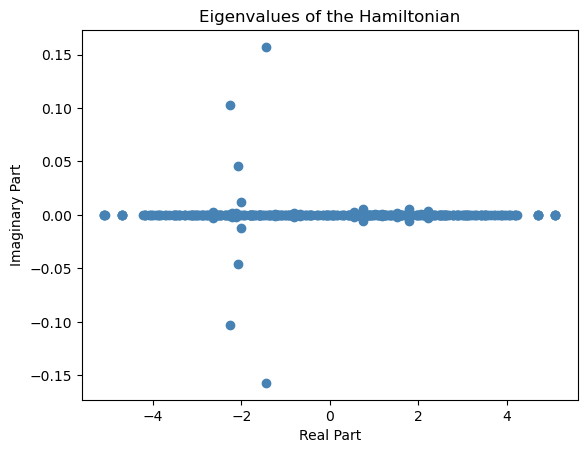

In [99]:
##plot the eigenvalues
e, v = np.linalg.eig(ham)
plt.plot(e.real, e.imag, 'o', color='steelblue')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.title('Eigenvalues of the Hamiltonian')

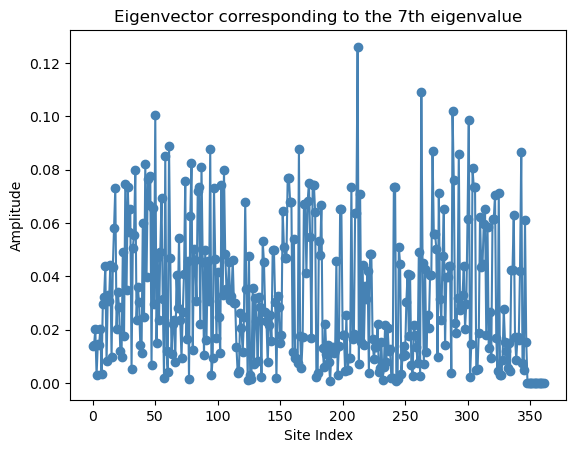

In [100]:
## plot one eigenvector
plt.figure()
plt.plot(np.abs(v[6]), 'o-', color='steelblue')
plt.xlabel('Site Index')
plt.ylabel('Amplitude')
plt.title('Eigenvector corresponding to the 7th eigenvalue')
plt.show()

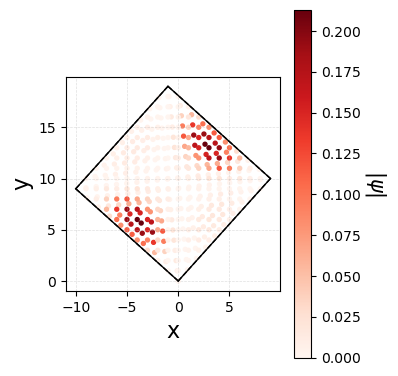

In [101]:
## Lets plot the |eigenvectors| (amplitude of a given state) of the Hamiltonian for a specific eigenvalue----
N = lattice_obc.lower_lattice.points.shape[0]
R =  6

plt.figure(figsize=(4, 4))
nx = lattice_obc.n1
ny = lattice_obc.n2
mlv1 = lattice_obc.mlv1
mlv2 = lattice_obc.mlv2

# Draw large unit cell
plt.plot([0, nx*mlv1[0]], [0, nx*mlv1[1]], 'k', linewidth=1)
plt.plot([0, ny*mlv2[0]], [0, ny*mlv2[1]], 'k', linewidth=1)
plt.plot([nx*mlv1[0], nx*mlv1[0] + ny*mlv2[0]], 
         [nx*mlv1[1], nx*mlv1[1] + ny*mlv2[1]], 'k', linewidth=1)
plt.plot([ny*mlv2[0], nx*mlv1[0] + ny*mlv2[0]], 
         [ny*mlv2[1], nx*mlv1[1] + ny*mlv2[1]], 'k', linewidth=1)

# Draw base unit cell
plt.plot([0, mlv1[0]], [0, mlv1[1]], 'k--', linewidth=1)
plt.plot([0, mlv2[0]], [0, mlv2[1]], 'k--', linewidth=1)
plt.plot([mlv1[0], mlv1[0] + mlv2[0]], 
         [mlv1[1], mlv1[1] + mlv2[1]], 'k--', linewidth=1)
plt.plot([mlv2[0], mlv1[0] + mlv2[0]], 
         [mlv2[1], mlv1[1] + mlv2[1]], 'k--', linewidth=1)

# Plot upper and lower lattice points
sc1 = plt.scatter(lattice_obc.upper_lattice.points[:, 0], 
                  lattice_obc.upper_lattice.points[:, 1],
                  c=np.abs(v[:N, R]), cmap='Reds', s=8, label='Upper')
sc2 = plt.scatter(lattice_obc.lower_lattice.points[:, 0], 
                  lattice_obc.lower_lattice.points[:, 1],
                  c=np.abs(v[N:, R]), cmap='Reds', s=8, label='Lower')

plt.gca().set_aspect('equal', adjustable='box')

# Colorbar
cbar = plt.colorbar(sc2)
cbar.set_label(r'$|\psi|$', rotation=270, labelpad=20, fontsize=15)

# Axis labels
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)

# Clean grid and layout
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()

plt.show()


In the eigenstate, we can see the pile up of the state (known as `Non-Hermitian Skin effect`). This example illustartes that you can use MoirePy to make a non-hermitian system and analyze such system. The more about this can be found **[here](examples.md)**.

## 8. Moiré System with Multiple Orbitals

We have explored so many phenomena with single orbital. Now, we will illustrate the Hamiltonian construction with multiple orbitals. 

In [102]:
from moirepy import BilayerMoireLattice, TriangularLayer

In [103]:
lattice = BilayerMoireLattice(
    latticetype=TriangularLayer,
    ll1=1, ll2=2,
    ul1=2, ul2=1,
    n1=1, n2=1,
    k = 2,
    pbc=True  # for k-space 
)

twist angle = 0.3803 rad (21.7868 deg)
7 cells in upper lattice
7 cells in lower lattice


In [107]:
lattice.generate_connections(inter_layer_radius=1)
real_ham = lattice.generate_hamiltonian(
    tll=[[1, 0], [0, 1]], tuu=1.2,
    tul=1, tlu=1,
    tuself=0.2, tlself=0.2
).toarray().real   ## How to set the multij orbital index for the hoppings?

TypeError: float() argument must be a string or a real number, not 'list'

In [92]:
print(f"Hamiltonian shape: {real_ham}")

Hamiltonian shape: [[0.2 0.2 2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  1.  1.  1.  1.
  1.  1.  0.  0.  0.  0.  0.  0.  1.  1. ]
 [0.2 0.2 2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  1.  1.  1.  1.
  1.  1.  0.  0.  0.  0.  0.  0.  1.  1. ]
 [2.  2.  0.2 0.2 2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  1.  1.  0.  0.
  1.  1.  1.  1.  0.  0.  1.  1.  0.  0. ]
 [2.  2.  0.2 0.2 2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  1.  1.  0.  0.
  1.  1.  1.  1.  0.  0.  1.  1.  0.  0. ]
 [2.  2.  2.  2.  0.2 0.2 2.  2.  2.  2.  2.  2.  2.  2.  0.  0.  0.  0.
  0.  0.  1.  1.  1.  1.  0.  0.  1.  1. ]
 [2.  2.  2.  2.  0.2 0.2 2.  2.  2.  2.  2.  2.  2.  2.  0.  0.  0.  0.
  0.  0.  1.  1.  1.  1.  0.  0.  1.  1. ]
 [2.  2.  2.  2.  2.  2.  0.2 0.2 2.  2.  2.  2.  2.  2.  1.  1.  1.  1.
  1.  1.  1.  1.  0.  0.  0.  0.  1.  1. ]
 [2.  2.  2.  2.  2.  2.  0.2 0.2 2.  2.  2.  2.  2.  2.  1.  1.  1.  1.
  1.  1.  1.  1.  0.  0.  0.  0.  1.  1. ]
 [2.  2.  2.  2.  2.  2.  2.  2.  0.2 0.2 2.  2.  2. 

## Summary

- All six hopping slots accept a **float, int, or any callable**; you can mix and match freely.
- Pair-hopping callables receive `(pos_i, pos_j, R, type_i, type_j, lattice, **kwargs)`; on-site callables receive `(pos_i, type_i, lattice, **kwargs)`.
- Pass extra parameters to your callable via the `extra_inputs` dict.
- Set `inter_layer_radius` larger than your largest `r_c`; let the hopping function handle suppression.
- For a Hermitian system, ensure `tlu` is the complex conjugate of `tul`.

## Next Steps

1. **[K-Space and Band Structures](k_space_hamiltonian.md)**: Fold this Hamiltonian into momentum space and compute a band structure.
2. **[OBC vs PBC](obc_vs_pbc.md)**: See how boundary conditions change the spectrum.
3. **[Tutorials and Replicated Papers](../examples.md)**: See full physical results with realistic hop models.